In [14]:
import pysces
import matplotlib.pyplot as plt

In [146]:
model = pysces.model(File = 'tgf_beta_smad.psc',dir='/home/cosmos/Documents/pysces')

Using model directory: /home/cosmos/Documents/pysces
/home/cosmos/Documents/pysces/tgf_beta_smad.psc loading ..... 
Parsing file: /home/cosmos/Documents/pysces/tgf_beta_smad.psc
Info: No reagents have been fixed
 
Calculating L matrix . . . . . . . . .  done.
Calculating K matrix . . . . . . .  done.
 


In [128]:
model.doState()

INFO: (hybrd) Invalid steady state:
(hybrd) The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
WARNING!! Negative concentrations detected.
INFO: STATE is switching to NLEQ2 solver.
(nleq2) exits with ierr = 21
WARNING!! Negative concentrations detected.
INFO: STATE is switching to FINTSLV solver.


In [142]:
model.showFluxRelationships()


Flux relationships
complex_formation = + {1.00}smad_complex_nuclear_import
seques_calveolar_t1r =
seques_endo_t1r = + {1.00}deg_endo_t1r
T2R_formation = - {1.00}deg_endo_t1r + {1.00}deg_endo_t2r + {1.00}T1R_formation + {1.00}eg2
seques_calveolar_t2r =
seques_endo_t2r = + {1.00}deg_endo_t2r + {1.00}eg2
LRC_formation = - {1.00}lrc_ee_degradation - {1.00}deg_endo_t1r + {1.00}T1R_formation - {1.00}smad_complex_nuclear_import + {1.00}eg2
eg1 = - {1.00}lrc_ee_degradation - {1.00}deg_endo_t1r + {1.00}T1R_formation - {1.00}smad_complex_nuclear_import
seques_calvelolar_lrc = - {2.00}lrc_ee_degradation - {1.00}deg_endo_t1r + {1.00}T1R_formation - {2.00}smad_complex_nuclear_import + {1.00}eg2
deseques_cal_t1r = - {1.00}lrc_ee_degradation - {1.00}smad_complex_nuclear_import + {1.00}eg2
seques_ee_lrc = + {1.00}lrc_ee_degradation + {1.00}smad_complex_nuclear_import
ligand_induced_degradation =
smad2_nuclear_import = - {1.00}smad_complex_nuclear_import
smad_complex_dissociation_nucleus = + {1.00}sma

In [134]:
model.doSim(end = 24, points = 10000)

/home/cosmos/stochpy/lib/python3.9/site-packages/pysces/PyscesModel.py:4051: ODEintWarning: Integration successful.
  sim_res, infodict = scipy.integrate.odeint(


LSODA time for 10000 points: 0.3846132755279541


LSODA time for 100 points: 0.0809628963470459


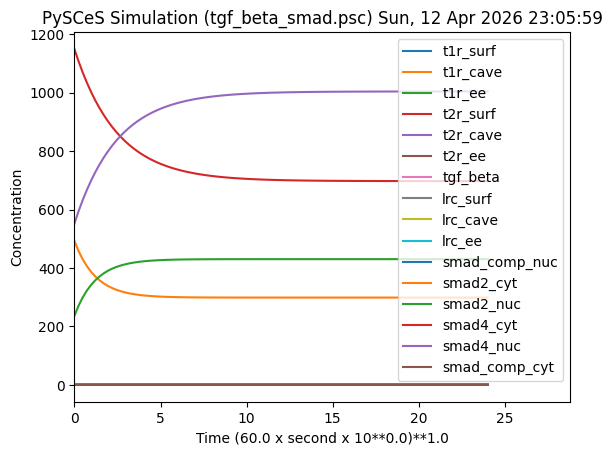

In [147]:
model.doSimPlot(end=24, points=100, plot='species', fmt='lines', filename=None)

In [145]:
model.showSpecies(),model.showSpeciesI()


Species values
t1r_surf = 2.3469e-01
t1r_cave = 2.0694e+00
t1r_ee = 2.0305e+00
t2r_surf = 1.9978e-01
t2r_cave = 1.7569e+00
t2r_ee = 1.1277e+00
tgf_beta = 8.0763e-08
lrc_surf = 5.7403e-05
lrc_cave = 1.7501e-02
lrc_ee = 1.3270e-06
smad_comp_nuc = 3.9630e-03
smad2_cyt = 2.9879e+02
smad2_nuc = 4.3026e+02
smad4_cyt = 6.9720e+02
smad4_nuc = 1.0039e+03
smad_comp_cyt = 4.0938e-05

Species initial values
t1r_surf_init = 2.3700e-01
t1r_cave_init = 2.0920e+00
t1r_ee_init = 2.0600e+00
t2r_surf_init = 2.0200e-01
t2r_cave_init = 1.7780e+00
t2r_ee_init = 1.1480e+00
tgf_beta_init = 8.0000e-02
lrc_surf_init = 1.0000e-08
lrc_cave_init = 1.0000e-08
lrc_ee_init = 1.0000e-08
smad_comp_nuc_init = 1.0000e-08
smad2_cyt_init = 4.9261e+02
smad2_nuc_init = 2.3645e+02
smad4_cyt_init = 1.1494e+03
smad4_nuc_init = 5.5172e+02
smad_comp_cyt_init = 1.0000e-08


(None, None)

In [148]:
model.showRateEq()


Reaction stoichiometry and rate equations
lrc_ee_degradation:
	lrc_ee > 
	kcd*lrc_ee
deg_endo_t1r:
	t1r_ee > 
	kdeg_t1r*t1r_ee
deg_endo_t2r:
	t2r_ee > 
	kdeg_t2r*t2r_ee
T1R_formation:
	 > t1r_surf
	v_tir
smad_complex_nuclear_import:
	smad_comp_cyt > smad_comp_nuc
	ksmad_imp*smad_comp_cyt*(V_cyt/V_nuc)
eg2:
	t2r_ee > tgf_beta
	kr_ee*t2r_ee*(V_cyt/V_extra)
complex_formation:
	smad2_cyt + smad4_cyt + lrc_ee > smad_comp_cyt
	ksmad*smad2_cyt*smad4_cyt*lrc_ee
seques_calveolar_t1r:
	t1r_surf = t1r_cave
	ki_cave*t1r_surf-kr_cave*t1r_cave
seques_endo_t1r:
	t1r_surf = t1r_ee
	ki_ee*t1r_surf-kr_ee*t1r_ee
T2R_formation:
	 > t2r_surf
	v_t2r
seques_calveolar_t2r:
	t2r_surf = t2r_cave
	ki_cave*t2r_surf-kr_cave*t2r_cave
seques_endo_t2r:
	t2r_surf = t2r_ee
	ki_ee*t2r_surf-kr_ee*t2r_ee
LRC_formation:
	t1r_surf + t2r_surf + tgf_beta > lrc_surf
	k_lrc*t1r_surf*t2r_surf*tgf_beta*V_cyt/V_extra
eg1:
	lrc_cave > tgf_beta
	kr_cave*lrc_cave*(V_cyt/V_extra)
seques_calvelolar_lrc:
	lrc_surf > lrc_cave
	ki_cave*l